# Regression - Predicting Values from Data

This notebook will teach you how to use machine learning to predict one value from other values in your data.

**What we'll learn:**
1. Choose what we want to predict (target) and what to use for prediction (features)
2. Split our data into training and testing sets
3. Try 3 different regression models
4. Compare which model works best
5. Make predictions on new data

**Example:**
We might predict salary based on experience, job type, and company size.

**Instructions:**
- Make sure you have clean data from the previous notebook (available on OneDrive)
- Run each cell one by one
- Choose your own features to experiment with!
- See section 10 for regularization 

In [7]:
# Import libraries for machine learning
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder, StandardScaler

print("Libraries imported successfully!")
print("Ready to build regression models!")
print("📊 Available preprocessing tools:")
print("- One-hot encoding: pd.get_dummies()")
print("- Label encoding: LabelEncoder()")
print("- Feature scaling: StandardScaler()")

Libraries imported successfully!
Ready to build regression models!
📊 Available preprocessing tools:
- One-hot encoding: pd.get_dummies()
- Label encoding: LabelEncoder()
- Feature scaling: StandardScaler()


## 1. Load Your Data

First, let's load our clean data from the previous notebook.

In [ ]:
# Load your clean data
df = pd.read_csv('content/cleaned_data.csv')

print(f"Data loaded successfully!")
print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")

# Look at the data
print("\nFirst few rows:")
df.head()

Data loaded successfully!
Shape: 64620 rows × 11 columns

First few rows:


,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2025,SE,FT,Solutions Engineer,214000,USD,214000,US,100,US,M
1,2025,MI,FT,Data Engineer,158800,USD,158800,AU,0,AU,M
2,2025,MI,FT,Data Engineer,139200,USD,139200,AU,0,AU,M
3,2025,EN,FT,Data Engineer,90000,USD,90000,US,0,US,M
4,2025,EN,FT,Data Engineer,80000,USD,80000,US,0,US,M


## 2. Choose What to Predict and What to Use for Prediction

We need to choose:
- **Target (Y)**: What we want to predict (must be a number)
- **Features (X)**: What we'll use to make the prediction (can be numbers or categories)

In [9]:
# Look at our columns to decide what to predict
print("Available columns in our dataset:")
for i, col in enumerate(df.columns, 1):
    print(f"{i}. {col} - {df[col].dtype}")

print("\nNumerical columns (good for prediction targets):")
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(numerical_cols)

print("\nAll columns (can be used as features):")
all_cols = df.columns.tolist()
print(all_cols)

Available columns in our dataset:
1. work_year - int64
2. experience_level - object
3. employment_type - object
4. job_title - object
5. salary - int64
6. salary_currency - object
7. salary_in_usd - int64
8. employee_residence - object
9. remote_ratio - int64
10. company_location - object
11. company_size - object

Numerical columns (good for prediction targets):
['work_year', 'salary', 'salary_in_usd', 'remote_ratio']

All columns (can be used as features):
['work_year', 'experience_level', 'employment_type', 'job_title', 'salary', 'salary_currency', 'salary_in_usd', 'employee_residence', 'remote_ratio', 'company_location', 'company_size']


In [10]:
# CHOOSE YOUR TARGET AND FEATURES HERE
# Change these to match your data and what you want to predict

# What we want to predict (must be numerical)
target_column = 'salary_in_usd'  # Change this to your target column

# What we'll use to make predictions (choose 2-5 columns)
feature_columns = ['experience_level', 'job_title', 'company_location']  # Change these

print(f"We want to predict: {target_column}")
print(f"Using these features: {feature_columns}")

# Check if our choices are valid
if target_column not in df.columns:
    print(f"ERROR: {target_column} not found in data")
else:
    print(f"✓ Target column '{target_column}' found")
    
missing_features = [col for col in feature_columns if col not in df.columns]
if missing_features:
    print(f"ERROR: These features not found: {missing_features}")
else:
    print("✓ All feature columns found")

We want to predict: salary_in_usd
Using these features: ['experience_level', 'job_title', 'company_location']
✓ Target column 'salary_in_usd' found
✓ All feature columns found


## 3. Prepare the Data for Machine Learning

We need to prepare our data so the computer can understand it. This involves:
1. **Encoding categorical features** - Converting text to numbers
2. **Scaling numerical features** - Making sure all features are on similar scales

**Two main encoding methods:**
- **One-hot encoding**: Creates separate columns for each category (good for few categories)
- **Label encoding**: Assigns numbers to categories (good for many categories)

In [11]:
# Create our target (Y) and features (X)
y = df[target_column]  # What we want to predict
X = df[feature_columns]  # What we'll use to predict

print("Data before preparation:")
print(f"Target shape: {y.shape}")
print(f"Features shape: {X.shape}")
print(f"Features data types:\n{X.dtypes}")

# Identify categorical and numerical features
categorical_features = X.select_dtypes(include=['object']).columns.tolist()
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()

print(f"\nCategorical features: {categorical_features}")
print(f"Numerical features: {numerical_features}")

# CHOOSE YOUR ENCODING METHOD HERE
# Option 1: One-hot encoding (creates separate columns for each category)
# Option 2: Label encoding (assigns numbers to categories)

ENCODING_METHOD = "one_hot"  # Change to "label" for label encoding

print(f"\n🔧 Using {ENCODING_METHOD} encoding for categorical features...")

if ENCODING_METHOD == "one_hot":
    # One-hot encoding: Good when you have few categories per feature
    X_encoded = pd.get_dummies(X, columns=categorical_features, drop_first=True)
    print(f"✓ One-hot encoding applied")
    print(f"  Original features: {X.shape[1]}")
    print(f"  After encoding: {X_encoded.shape[1]} features")
    
elif ENCODING_METHOD == "label":
    # Label encoding: Good when you have many categories or ordinal data
    X_encoded = X.copy()
    label_encoders = {}
    
    for feature in categorical_features:
        le = LabelEncoder()
        X_encoded[feature] = le.fit_transform(X[feature].astype(str))
        label_encoders[feature] = le
        print(f"  {feature}: {len(le.classes_)} categories → 0 to {len(le.classes_)-1}")
    
    print(f"✓ Label encoding applied")
    print(f"  Features remain: {X_encoded.shape[1]} (same as original)")

print(f"\nNew feature names: {list(X_encoded.columns)}")

# Remove any rows with missing values
mask = ~(X_encoded.isnull().any(axis=1) | y.isnull())
X_clean = X_encoded[mask]
y_clean = y[mask]

print(f"\nAfter removing missing values:")
print(f"Final dataset size: {len(X_clean)} rows")
print(f"Features: {X_clean.shape[1]} columns")

Data before preparation:
Target shape: (64620,)
Features shape: (64620, 3)
Features data types:
experience_level    object
job_title           object
company_location    object
dtype: object

Categorical features: ['experience_level', 'job_title', 'company_location']
Numerical features: []

🔧 Using one_hot encoding for categorical features...
✓ One-hot encoding applied
  Original features: 3
  After encoding: 486 features

New feature names: ['experience_level_EX', 'experience_level_MI', 'experience_level_SE', 'job_title_AI Content Writer', 'job_title_AI Data Engineer', 'job_title_AI Data Scientist', 'job_title_AI Developer', 'job_title_AI Engineer', 'job_title_AI Engineering Lead', 'job_title_AI Engineering Manager', 'job_title_AI Governance Lead', 'job_title_AI Governance Specialist', 'job_title_AI Lead', 'job_title_AI Machine Learning Engineer', 'job_title_AI Product Lead', 'job_title_AI Product Manager', 'job_title_AI Product Owner', 'job_title_AI Programmer', 'job_title_AI Researc

### 🤔 Understanding Encoding Methods

**When to use One-Hot Encoding:**
- ✅ Few categories per feature (2-10 categories)
- ✅ Categories have no natural order (e.g., colors, countries)
- ✅ You want the model to treat each category independently
- ❌ Avoid with many categories (creates too many features)

**When to use Label Encoding:**
- ✅ Many categories per feature (10+ categories)
- ✅ Categories have natural order (e.g., low/medium/high)
- ✅ Memory/speed is important (fewer features)
- ❌ Avoid when categories have no meaningful order (model may assume ranking)

**Experiment:** Try changing `ENCODING_METHOD` above and see how it affects your results!

In [12]:
# STEP 2: Feature Scaling (Normalization)
# This ensures all features are on similar scales (important for Linear Regression!)

APPLY_SCALING = True  # Change to False if you don't want scaling

if APPLY_SCALING:
    print("🔧 APPLYING FEATURE SCALING")
    print("=" * 40)
    
    # Show feature ranges before scaling (only for numerical features)
    print("Feature statistics BEFORE scaling:")
    
    # For one-hot encoded data, show value counts instead of ranges
    if ENCODING_METHOD == "one_hot":
        print(f"One-hot encoded features: {X_clean.shape[1]} binary columns")
        print(f"Data type: {X_clean.dtypes.iloc[0]} (0s and 1s)")
        print(f"Sample feature values: {X_clean.iloc[0].sum()} features = 1 for first row")
    else:
        # For label encoded data, we can show ranges
        feature_ranges_before = X_clean.max() - X_clean.min()
        print("Feature ranges:")
        print(feature_ranges_before.describe())
    
    # Apply StandardScaler (mean=0, std=1)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_clean)
    X_scaled = pd.DataFrame(X_scaled, columns=X_clean.columns, index=X_clean.index)
    
    # Show feature statistics after scaling
    print(f"\nFeature statistics AFTER scaling:")
    print(f"Mean values (should be ≈ 0): {X_scaled.mean().mean():.6f}")
    print(f"Standard deviation (should be ≈ 1): {X_scaled.std().mean():.6f}")
    feature_ranges_after = X_scaled.max() - X_scaled.min()
    print(f"Average range after scaling: {feature_ranges_after.mean():.3f}")
    
    print(f"\n✓ Feature scaling applied!")
    print(f"  All features now have mean ≈ 0 and std ≈ 1")
    print(f"  This helps Linear Regression perform better")
    
    # Use scaled features
    X_final = X_scaled
    
else:
    print("⚠️  Skipping feature scaling")
    if ENCODING_METHOD == "one_hot":
        print("Note: One-hot encoded features are already 0/1, scaling less critical")
    else:
        print("Note: Linear Regression may perform poorly with unscaled features")
    X_final = X_clean

print(f"\n📊 FINAL PREPARED DATA:")
print(f"Features shape: {X_final.shape}")
print(f"Target shape: {y_clean.shape}")
print(f"Ready for machine learning!")

🔧 APPLYING FEATURE SCALING
Feature statistics BEFORE scaling:
One-hot encoded features: 486 binary columns
Data type: bool (0s and 1s)
Sample feature values: 3 features = 1 for first row

Feature statistics AFTER scaling:
Mean values (should be ≈ 0): -0.000000

Feature statistics AFTER scaling:
Mean values (should be ≈ 0): -0.000000
Standard deviation (should be ≈ 1): 1.000008
Average range after scaling: 96.719

✓ Feature scaling applied!
  All features now have mean ≈ 0 and std ≈ 1
  This helps Linear Regression perform better

📊 FINAL PREPARED DATA:
Features shape: (64620, 486)
Target shape: (64620,)
Ready for machine learning!
Standard deviation (should be ≈ 1): 1.000008
Average range after scaling: 96.719

✓ Feature scaling applied!
  All features now have mean ≈ 0 and std ≈ 1
  This helps Linear Regression perform better

📊 FINAL PREPARED DATA:
Features shape: (64620, 486)
Target shape: (64620,)
Ready for machine learning!


## 4. Split Data into Training and Testing Sets

We'll use 80% of our data to train the model and 20% to test how well it works.

In [13]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y_clean,   # Use our prepared features and clean target
    test_size=0.2,      # Use 20% for testing
    random_state=42     # For reproducible results
)

print("Data split successfully!")
print(f"Training set: {X_train.shape[0]} rows")
print(f"Testing set: {X_test.shape[0]} rows")
print(f"Features: {X_train.shape[1]} columns")

print(f"\nTarget variable summary:")
print(f"Training target range: {y_train.min():.0f} to {y_train.max():.0f}")
print(f"Testing target range: {y_test.min():.0f} to {y_test.max():.0f}")

if APPLY_SCALING:
    print(f"\n✓ Using scaled features for training")
    print(f"  Feature means ≈ 0, standard deviations ≈ 1")
else:
    print(f"\n⚠️  Using unscaled features for training")

Data split successfully!
Training set: 51696 rows
Testing set: 12924 rows
Features: 486 columns

Target variable summary:
Training target range: 15000 to 800000
Testing target range: 15000 to 800000

✓ Using scaled features for training
  Feature means ≈ 0, standard deviations ≈ 1


## 5. Train Three Different Regression Models

Let's try three different types of models and see which works best!

In [ ]:
# Model 1: Linear Regression (draws a straight line through the data)
print("Training Model 1: Linear Regression")
model1 = LinearRegression()
model1.fit(X_train, y_train)

# Make predictions
y_pred1 = model1.predict(X_test)

# Calculate performance
mse1 = mean_squared_error(y_test, y_pred1)
r2_1 = r2_score(y_test, y_pred1)

print(f"✓ Linear Regression trained!")
print(f"  Mean Squared Error: {mse1:.2f}")
print(f"  R² Score: {r2_1:.3f} (higher is better, max = 1.0)")


Training Model 1: Linear Regression
✓ Linear Regression (Ridge) trained!
  Mean Squared Error: 2487450763013105885183483489112031232.00
  R² Score: -420417856670904113222909952.000 (higher is better, max = 1.0)
✓ Linear Regression (Ridge) trained!
  Mean Squared Error: 2487450763013105885183483489112031232.00
  R² Score: -420417856670904113222909952.000 (higher is better, max = 1.0)


In [ ]:
# Model 2: Decision Tree (will see this in Classification, but can be applied to Regression problems)
print("Training Model 2: Decision Tree")
model2 = DecisionTreeRegressor(random_state=42, max_depth=10)
model2.fit(X_train, y_train)

# Make predictions
y_pred2 = model2.predict(X_test)

# Calculate performance
mse2 = mean_squared_error(y_test, y_pred2)
r2_2 = r2_score(y_test, y_pred2)

print(f"✓ Decision Tree trained!")
print(f"  Mean Squared Error: {mse2:.2f}")
print(f"  R² Score: {r2_2:.3f} (higher is better, max = 1.0)")

Training Model 2: Decision Tree
✓ Decision Tree trained!
  Mean Squared Error: 4536532182.32
  R² Score: 0.233 (higher is better, max = 1.0)
✓ Decision Tree trained!
  Mean Squared Error: 4536532182.32
  R² Score: 0.233 (higher is better, max = 1.0)


In [16]:
# Model 3: Random Forest (combines many decision trees)
print("Training Model 3: Random Forest")
model3 = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=10)
model3.fit(X_train, y_train)

# Make predictions
y_pred3 = model3.predict(X_test)

# Calculate performance
mse3 = mean_squared_error(y_test, y_pred3)
r2_3 = r2_score(y_test, y_pred3)

print(f"✓ Random Forest trained!")
print(f"  Mean Squared Error: {mse3:.2f}")
print(f"  R² Score: {r2_3:.3f} (higher is better, max = 1.0)")

Training Model 3: Random Forest
✓ Random Forest trained!
  Mean Squared Error: 4471097312.95
  R² Score: 0.244 (higher is better, max = 1.0)
✓ Random Forest trained!
  Mean Squared Error: 4471097312.95
  R² Score: 0.244 (higher is better, max = 1.0)


## 6. Compare the Models

Let's see which model performed best on our test data!

In [17]:
# Compare all models
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Decision Tree', 'Random Forest'],
    'Mean_Squared_Error': [mse1, mse2, mse3],
    'R2_Score': [r2_1, r2_2, r2_3]
})

print("🏆 MODEL COMPARISON RESULTS")
print("=" * 50)
print(results.to_string(index=False, float_format='%.3f'))

# Find the best model
best_model_idx = results['R2_Score'].idxmax()
best_model_name = results.loc[best_model_idx, 'Model']
best_r2 = results.loc[best_model_idx, 'R2_Score']

print(f"\n🥇 WINNER: {best_model_name}")
print(f"   R² Score: {best_r2:.3f}")

print(f"\nHow to interpret R² Score:")
print(f"- 1.0 = Perfect predictions")
print(f"- 0.8+ = Very good")
print(f"- 0.6+ = Good") 
print(f"- 0.4+ = Okay")
print(f"- Below 0.4 = Needs improvement")

🏆 MODEL COMPARISON RESULTS
            Model                        Mean_Squared_Error                         R2_Score
Linear Regression 2487450763013105885183483489112031232.000 -420417856670904113222909952.000
    Decision Tree                            4536532182.324                            0.233
    Random Forest                            4471097312.950                            0.244

🥇 WINNER: Random Forest
   R² Score: 0.244

How to interpret R² Score:
- 1.0 = Perfect predictions
- 0.8+ = Very good
- 0.6+ = Good
- 0.4+ = Okay
- Below 0.4 = Needs improvement


## 7. Visualise the Results

Let's create plots to see how well our models performed.

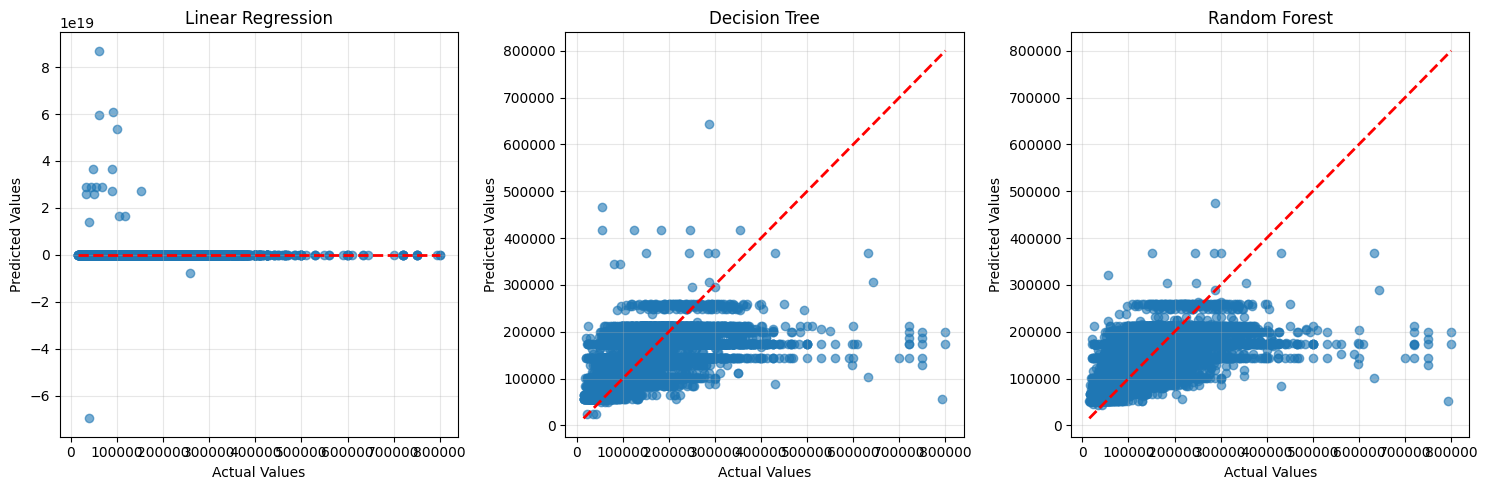

How to read these plots:
- Points close to the red line = good predictions
- Points far from the red line = poor predictions
- Tighter cluster around the line = better model


In [18]:
# Plot actual vs predicted values for each model
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

models = [
    ('Linear Regression', y_pred1),
    ('Decision Tree', y_pred2), 
    ('Random Forest', y_pred3)
]

for i, (name, predictions) in enumerate(models):
    axes[i].scatter(y_test, predictions, alpha=0.6)
    axes[i].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    axes[i].set_xlabel('Actual Values')
    axes[i].set_ylabel('Predicted Values')
    axes[i].set_title(f'{name}')
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("How to read these plots:")
print("- Points close to the red line = good predictions")
print("- Points far from the red line = poor predictions")
print("- Tighter cluster around the line = better model")

🔍 FEATURE IMPORTANCE (Random Forest)
This shows which features matter most for predictions:
                                            Feature  Importance
                                company_location_US       0.269
                                experience_level_SE       0.170
                                experience_level_EX       0.104
                                experience_level_MI       0.072
                             job_title_Data Analyst       0.066
                      job_title_Engineering Manager       0.049
                                company_location_CA       0.041
                job_title_Machine Learning Engineer       0.041
                                  job_title_Analyst       0.027
                       job_title_Research Scientist       0.024
                        job_title_Software Engineer       0.024
                        job_title_Research Engineer       0.019
                                company_location_GB       0.012
            

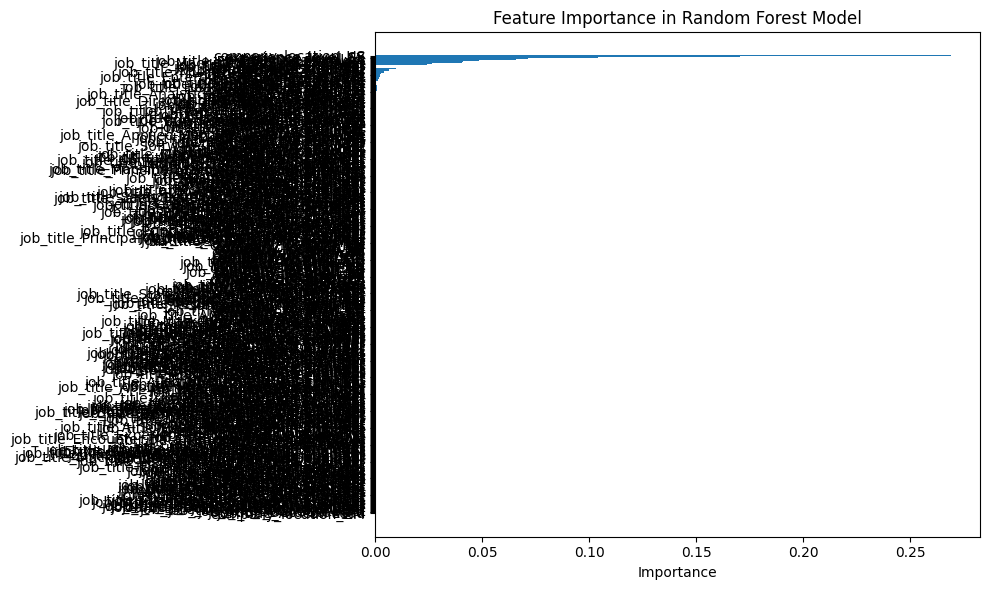


💡 Understanding Feature Importance:
- Higher values = more important for predictions
- Random Forest calculates this automatically
- Sum of all importances = 1.0
- One-hot encoded features may split importance across columns


In [19]:
# Show which features are most important (for Random Forest)
print("🔍 FEATURE IMPORTANCE (Random Forest)")
print("This shows which features matter most for predictions:")
print("=" * 60)

feature_importance = pd.DataFrame({
    'Feature': X_final.columns,  # Use the final prepared features
    'Importance': model3.feature_importances_
}).sort_values('Importance', ascending=False)

print(feature_importance.to_string(index=False, float_format='%.3f'))

# Plot feature importance
plt.figure(figsize=(10, 6))
plt.barh(range(len(feature_importance)), feature_importance['Importance'])
plt.yticks(range(len(feature_importance)), feature_importance['Feature'])
plt.xlabel('Importance')
plt.title('Feature Importance in Random Forest Model')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(f"\n💡 Understanding Feature Importance:")
print(f"- Higher values = more important for predictions")
print(f"- Random Forest calculates this automatically")
print(f"- Sum of all importances = 1.0")
if ENCODING_METHOD == "one_hot":
    print(f"- One-hot encoded features may split importance across columns")

## 8. Make Predictions on New Data

Now let's use our best model to make predictions!

In [20]:
# Use the best model to make predictions
models = [model1, model2, model3]
best_model = models[best_model_idx]

print(f"Using {best_model_name} for predictions")

# Example: Make predictions on a few test cases
print("\n📊 SAMPLE PREDICTIONS")
print("=" * 50)

# Show first 5 predictions vs actual values
sample_size = min(5, len(X_test))
sample_predictions = best_model.predict(X_test.iloc[:sample_size])

for i in range(sample_size):
    actual = y_test.iloc[i]
    predicted = sample_predictions[i]
    error = abs(actual - predicted)
    
    print(f"Case {i+1}:")
    print(f"  Actual: {actual:.0f}")
    print(f"  Predicted: {predicted:.0f}")
    print(f"  Error: {error:.0f}")
    print()

print("💡 TIP: You can use this model to predict new values!")
print("Just create a new row with the same features and use model.predict()")

Using Random Forest for predictions

📊 SAMPLE PREDICTIONS
Case 1:
  Actual: 120000
  Predicted: 174549
  Error: 54549

Case 2:
  Actual: 205412
  Predicted: 174352
  Error: 31060

Case 3:
  Actual: 265000
  Predicted: 175140
  Error: 89860

Case 4:
  Actual: 163500
  Predicted: 101672
  Error: 61828

Case 5:
  Actual: 50000
  Predicted: 101121
  Error: 51121

💡 TIP: You can use this model to predict new values!
Just create a new row with the same features and use model.predict()


## 9. Summary so far

**🎉 Congratulations! You've built your first regression models!**

**What we learned:**
- How to choose target variables and features
- How to prepare data for machine learning
- How to split data into training and testing sets
- How to train 3 different regression models
- How to compare model performance
- How to make predictions on new data

**Key takeaways:**
- **Linear Regression**: Simple, interpretable, good for linear relationships
- **Decision Tree**: Handles non-linear patterns, easy to understand
- **Random Forest**: Often the most accurate, combines many trees

**Try this next:**
1. Change the target variable to predict something else
2. Add or remove features to see how it affects performance
3. Try different train/test split ratios
4. Experiment with different datasets

**Remember:**
- Higher R² score = better model (closer to 1.0)
- Always test on unseen data
- More data usually means better models
- Feature selection matters!

## 10. Regularized Linear Regression

Sometimes Linear Regression can have problems with certain features. Let's try regularized versions that are more robust!

In [21]:
# Import regularized regression models
from sklearn.linear_model import Ridge, Lasso

print("What is regularization?")
print("- Regularization helps prevent overfitting")
print("- It makes models more stable with difficult features")
print("- Ridge and Lasso are two common types")
print("- They work better when you have many features or correlated features")
print("\nLet's try them!")

What is regularization?
- Regularization helps prevent overfitting
- It makes models more stable with difficult features
- Ridge and Lasso are two common types
- They work better when you have many features or correlated features

Let's try them!


In [22]:
# Model 4: Ridge Regression (Linear Regression with L2 regularization)
print("Training Model 4: Ridge Regression")
model4 = Ridge(alpha=1.0, random_state=42)
model4.fit(X_train, y_train)

# Make predictions
y_pred4 = model4.predict(X_test)

# Calculate performance
mse4 = mean_squared_error(y_test, y_pred4)
r2_4 = r2_score(y_test, y_pred4)

print(f"✓ Ridge Regression trained!")
print(f"  Mean Squared Error: {mse4:.2f}")
print(f"  R² Score: {r2_4:.3f} (higher is better, max = 1.0)")
print(f"  Ridge helps when features are correlated")

Training Model 4: Ridge Regression
✓ Ridge Regression trained!
  Mean Squared Error: 4266536990.40
  R² Score: 0.279 (higher is better, max = 1.0)
  Ridge helps when features are correlated
✓ Ridge Regression trained!
  Mean Squared Error: 4266536990.40
  R² Score: 0.279 (higher is better, max = 1.0)
  Ridge helps when features are correlated


In [23]:
# Model 5: Lasso Regression (Linear Regression with L1 regularization)
print("Training Model 5: Lasso Regression")
model5 = Lasso(alpha=1.0, random_state=42, max_iter=1000)
model5.fit(X_train, y_train)

# Make predictions
y_pred5 = model5.predict(X_test)

# Calculate performance
mse5 = mean_squared_error(y_test, y_pred5)
r2_5 = r2_score(y_test, y_pred5)

print(f"✓ Lasso Regression trained!")
print(f"  Mean Squared Error: {mse5:.2f}")
print(f"  R² Score: {r2_5:.3f} (higher is better, max = 1.0)")
print(f"  Lasso automatically selects important features")

Training Model 5: Lasso Regression
✓ Lasso Regression trained!
  Mean Squared Error: 4266931746.52
  R² Score: 0.279 (higher is better, max = 1.0)
  Lasso automatically selects important features
✓ Lasso Regression trained!
  Mean Squared Error: 4266931746.52
  R² Score: 0.279 (higher is better, max = 1.0)
  Lasso automatically selects important features


/opt/miniconda3/envs/sc2024/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.625e+13, tolerance: 3.120e+10
  model = cd_fast.enet_coordinate_descent(


In [24]:
# Compare ALL models including regularized ones
all_results = pd.DataFrame({
    'Model': ['Linear Regression', 'Decision Tree', 'Random Forest', 'Ridge Regression', 'Lasso Regression'],
    'Mean_Squared_Error': [mse1, mse2, mse3, mse4, mse5],
    'R2_Score': [r2_1, r2_2, r2_3, r2_4, r2_5]
})

print("🏆 COMPLETE MODEL COMPARISON")
print("=" * 60)
print(all_results.to_string(index=False, float_format='%.3f'))

# Find the best model overall
best_overall_idx = all_results['R2_Score'].idxmax()
best_overall_name = all_results.loc[best_overall_idx, 'Model']
best_overall_r2 = all_results.loc[best_overall_idx, 'R2_Score']

print(f"\n🥇 OVERALL WINNER: {best_overall_name}")
print(f"   R² Score: {best_overall_r2:.3f}")

print(f"\n📚 When to use each model:")
print(f"- Linear Regression: Simple relationships, interpretable")
print(f"- Ridge Regression: When features are correlated, more stable")
print(f"- Lasso Regression: Automatic feature selection, sparse solutions")
print(f"- Decision Tree: Non-linear patterns, easy to explain")
print(f"- Random Forest: Best overall performance, handles everything")

🏆 COMPLETE MODEL COMPARISON
            Model                        Mean_Squared_Error                         R2_Score
Linear Regression 2487450763013105885183483489112031232.000 -420417856670904113222909952.000
    Decision Tree                            4536532182.324                            0.233
    Random Forest                            4471097312.950                            0.244
 Ridge Regression                            4266536990.402                            0.279
 Lasso Regression                            4266931746.519                            0.279

🥇 OVERALL WINNER: Ridge Regression
   R² Score: 0.279

📚 When to use each model:
- Linear Regression: Simple relationships, interpretable
- Ridge Regression: When features are correlated, more stable
- Lasso Regression: Automatic feature selection, sparse solutions
- Decision Tree: Non-linear patterns, easy to explain
- Random Forest: Best overall performance, handles everything


In [25]:
# Show how Lasso selects features (sets some coefficients to zero)
print("🔍 FEATURE SELECTION BY LASSO")
print("=" * 50)

# Get coefficients for Ridge and Lasso
ridge_coef = pd.DataFrame({
    'Feature': X_final.columns,  # Use final prepared features
    'Ridge_Coefficient': model4.coef_
})

lasso_coef = pd.DataFrame({
    'Feature': X_final.columns,  # Use final prepared features
    'Lasso_Coefficient': model5.coef_
})

# Combine and show
feature_coef = pd.merge(ridge_coef, lasso_coef, on='Feature')
feature_coef['Lasso_Selected'] = (feature_coef['Lasso_Coefficient'] != 0)

print("Feature coefficients (Ridge vs Lasso):")
print(feature_coef.to_string(index=False, float_format='%.3f'))

# Count features selected by Lasso
selected_features = feature_coef['Lasso_Selected'].sum()
total_features = len(feature_coef)

print(f"\n📊 Lasso selected {selected_features} out of {total_features} features")
print(f"Features with coefficient = 0 are considered unimportant by Lasso")

if ENCODING_METHOD == "one_hot":
    print(f"\n💡 With one-hot encoding:")
    print(f"- Lasso might select only some categories from a feature")
    print(f"- This helps identify which specific categories matter most")
elif ENCODING_METHOD == "label":
    print(f"\n💡 With label encoding:")
    print(f"- Lasso selects entire features (not individual categories)")
    print(f"- Coefficients show direction and strength of relationship")

🔍 FEATURE SELECTION BY LASSO
Feature coefficients (Ridge vs Lasso):
                                            Feature  Ridge_Coefficient  Lasso_Coefficient  Lasso_Selected
                                experience_level_EX          13302.871          13300.153            True
                                experience_level_MI           8132.514           8126.327            True
                                experience_level_SE          21301.372          21305.761            True
                        job_title_AI Content Writer           -990.430           -968.339            True
                         job_title_AI Data Engineer           -548.266           -531.457            True
                        job_title_AI Data Scientist           -895.620           -858.433            True
                             job_title_AI Developer          -2016.816          -1874.615            True
                              job_title_AI Engineer          -3512.684          -315

### 💡 Troubleshooting Tips

**If you get errors with Linear Regression:**

1. **"Singular matrix" or "LinAlgError"**: 
   - Use Ridge or Lasso instead
   - Remove highly correlated features
   - Reduce the number of features

2. **Poor performance (low R² score)**:
   - Try regularized models (Ridge/Lasso)
   - Add more relevant features
   - Check for outliers in your data

3. **"Convergence warnings"**:
   - Increase `max_iter` parameter
   - Try Ridge regression instead
   - Standardize your features first

**Remember**: Ridge and Lasso are more robust than basic Linear Regression!

## 🔬 Experiment with Preprocessing Choices

**Now that you've completed the analysis, try these experiments:**

### Encoding Experiments:
1. **Change `ENCODING_METHOD`** from "one_hot" to "label" (or vice versa)
2. **Re-run all cells** from Section 3 onwards
3. **Compare results:** Which encoding gives better R² scores?

### Scaling Experiments:
1. **Change `APPLY_SCALING`** from True to False (or vice versa)
2. **Re-run from Section 3** onwards  
3. **Notice:** How much does scaling affect Linear/Ridge/Lasso vs Tree-based models?

### Expected Observations:
- **Linear models** (Linear/Ridge/Lasso) are very sensitive to scaling
- **Tree models** (Decision Tree/Random Forest) are less affected by scaling
- **One-hot encoding** creates more features but treats categories independently
- **Label encoding** assumes ordinal relationships between categories

### Questions to Explore:
1. Which combination gives the best performance for your data?
2. How does the number of features change with different encoding?
3. Which features does Lasso select with each encoding method?
4. Do the feature importance rankings change?

**Pro Tip:** The best preprocessing depends on your specific data and problem!